# Model comparison: Athena/Phoenix across models
This notebook compares **Price + Greeks** across models and plots metrics vs **spot** and **remaining maturity**.

Run from repo root after:

```bash
pip install -e .
```


In [1]:

import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


root = os.getcwd()
src = os.path.join(root, "src")
if os.path.isdir(src) and src not in sys.path:
    sys.path.insert(0, src)

from pricer.core.models import Model
from pricer.core.pricing import MonteCarloPricer
from pricer.core.greeks import Greeks
from pricer.core.observation import ObservationFrequency
from pricer.core.products import AutocallAthenaProduct, AutocallPhoenixProduct

from pricer.main import load_funding_curve


In [2]:

S0 = 100.0
STEPS_PER_YEAR = 52
N_PATHS = 10_000
ANTITHETIC = True
CONTROL_VARIATE = True

FUNDING_CURVE_XLSX = None  # e.g. "data/FundingCurve.xlsx"
CALIB_FILES = {
    # "rbergomi": "calib_rbergomi.json",
    # "rbergomi_hw": "calib_rbergomi_hw.json",
    # "heston": "calib_heston.json",
    # "heston_hw": "calib_heston_hw.json",
}

disc_times = disc_rates = None
if FUNDING_CURVE_XLSX:
    disc_times, disc_rates = load_funding_curve(FUNDING_CURVE_XLSX)
    print("Loaded curve pillars:", len(disc_times))


In [3]:

def make_athena(T=5.0):
    return AutocallAthenaProduct(
        nominal=100.0,
        strike=100.0,
        coupon_per_year=0.04,
        maturity_years_=float(T),
        obs_freq=ObservationFrequency.ANNUAL,
        call_barrier=1.0,
        protection_barrier=0.7,
        steps_per_year=STEPS_PER_YEAR,
    )

def make_phoenix(T=5.0):
    return AutocallPhoenixProduct(
        nominal=100.0,
        strike=100.0,
        coupon_per_year=0.06,
        maturity_years_=float(T),
        obs_freq=ObservationFrequency.ANNUAL,
        call_barrier=1.0,
        pheonix_barrier=0.7,
        protection_barrier=0.6,
        steps_per_year=STEPS_PER_YEAR,
    )

product = make_athena(5.0)


In [4]:

def load_calib(path):
    with open(path, "r") as f:
        return json.load(f)

def apply_calib(model: Model, calib: dict):
    for k,v in calib.items():
        if hasattr(model, k):
            setattr(model, k, v)
    if "xi0_times" in calib and "xi0_values" in calib:
        model.xi0_times = np.array(calib["xi0_times"], dtype=float)
        model.xi0_values = np.array(calib["xi0_values"], dtype=float)


In [5]:

def build_model(name: str, s0: float) -> Model:
    name = name.lower()
    # base
    m = Model(
        spot_process="GBM",
        rate_process="FLAT",
        vol_process="FLAT",
        s0=float(s0),
        r0=0.02,
        sigma=0.20,
        steps_per_year=STEPS_PER_YEAR,
        n_paths=N_PATHS,
        seed=1234,
        disc_times=disc_times,
        disc_rates=disc_rates,
    )

    if name == "gbm":
        m.spot_process="GBM"; m.rate_process="FLAT"; m.vol_process="FLAT"

    elif name == "heston":
        m.spot_process="HESTON"; m.rate_process="FLAT"; m.vol_process="HESTON"
        m.v0=0.04; m.kappa=2.0; m.theta=0.04; m.xi=0.5; m.rho_sv=-0.7

    elif name == "heston_hw":
        m.spot_process="HESTON"; m.rate_process="HULLWHITE"; m.vol_process="HESTON"
        m.v0=0.04; m.kappa=2.0; m.theta=0.04; m.xi=0.5; m.rho_sv=-0.7
        m.a=0.1; m.b=0.02; m.sigma_r=0.01; m.rho_sr=0.0; m.rho_vr=0.0

    elif name == "rbergomi":
        m.spot_process="GBM"; m.rate_process="FLAT"; m.vol_process="RBERGOMI"
        m.rough_H=0.1; m.rough_nu=1.0; m.rough_rho=-0.7

    elif name == "rbergomi_hw":
        m.spot_process="GBM"; m.rate_process="HULLWHITE"; m.vol_process="RBERGOMI"
        m.rough_H=0.1; m.rough_nu=1.0; m.rough_rho=-0.7
        m.a=0.1; m.b=0.02; m.sigma_r=0.01; m.rho_sr=0.0; m.rho_vr=0.0

    else:
        raise ValueError(name)

    if name in CALIB_FILES and CALIB_FILES[name]:
        calib = load_calib(CALIB_FILES[name])
        apply_calib(m, calib)

    
    m._build_correlations()
    return m

MODELS = ["gbm","heston","heston_hw","rbergomi","rbergomi_hw"]


In [6]:

def price_and_greeks(prod, model_name: str, s0: float):
    model = build_model(model_name, s0)
    pricer = MonteCarloPricer(antithetic=ANTITHETIC, control_variate=CONTROL_VARIATE)
    greeks = Greeks(model=model, pricer=pricer)

    price, se = pricer.price(prod, model)
    out = {
        "model": model_name,
        "price": float(price),
        "SE": float(se),
        "delta": greeks.delta(prod, rel_bump=0.005, central=True),
        "gamma": greeks.gamma(prod, rel_bump=0.005),
        "vega": greeks.vega(prod, vol_param="auto", rel_bump=0.01, central=True),
        "vega_meaning": greeks.vega_meaning("auto"),
        "rho_DV01": greeks.rho(prod, central=True),
        "vanna": greeks.vanna(prod, vol_param="auto", rel_bump=0.01),
        "volga": greeks.volga(prod, vol_param="auto", rel_bump=0.01),
    }
    return out

df0 = pd.DataFrame([price_and_greeks(product, m, S0) for m in MODELS]).set_index("model")
df0


,price,SE,delta,gamma,vega,vega_meaning,rho_DV01,vanna,volga
model,,,,,,,,,
gbm,92.243884,0.164901,0.482822,-0.086263,-0.598528,Vega wrt GBM volatility σ (per +1 vol point = ...,-0.006780,0.035343,-0.630740
heston,93.934604,0.161049,0.335876,-0.151306,-0.094630,Vega wrt Heston initial variance v0 (per +1% r...,-0.007651,-0.001357,7.335992
heston_hw,93.997124,0.162177,0.413156,0.055221,-0.379794,Vega wrt Heston initial variance v0 (per +1% r...,-0.009344,-0.101959,-3.144021
rbergomi,94.528448,0.145778,0.326711,-0.109363,0.018499,Vega wrt rough vol-of-vol ν (per +1% relative ...,-0.009391,-0.002080,0.007028
rbergomi_hw,94.278748,0.149394,0.370382,0.044889,0.023073,Vega wrt rough vol-of-vol ν (per +1% relative ...,-0.006938,-0.001478,-0.021238


## Plots vs spot

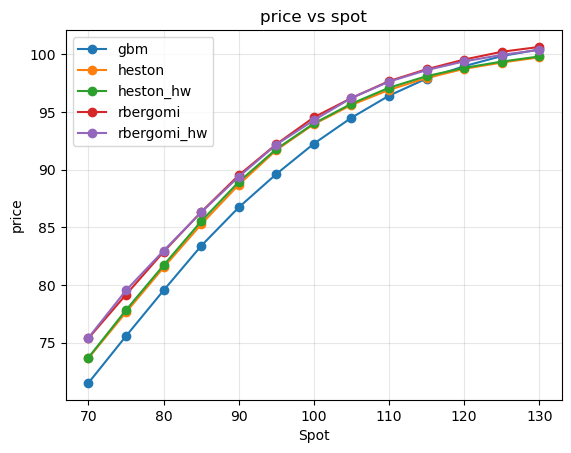

In [ ]:

spot_grid = np.linspace(0.7*S0, 1.3*S0, 13)

def sweep(metric: str, prod, model_name: str):
    vals=[]
    for s in spot_grid:
        vals.append(price_and_greeks(prod, model_name, float(s))[metric])
    return np.array(vals, dtype=float)

for metric in ["price","delta","gamma","vega","rho_DV01"]:
    plt.figure()
    for m in MODELS:
        plt.plot(spot_grid, sweep(metric, product, m), marker="o", label=m)
    plt.xlabel("Spot"); plt.ylabel(metric); plt.title(f"{metric} vs spot")
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()


## Plots vs remaining maturity

In [ ]:

T_grid = [5.0,4.0,3.0,2.0,1.0,0.5]

def make_like(prod, T):
    return make_athena(T) if isinstance(prod, AutocallAthenaProduct) else make_phoenix(T)

for metric in ["price","delta","gamma","vega"]:
    plt.figure()
    for m in MODELS:
        y=[]
        for T in T_grid:
            y.append(price_and_greeks(make_like(product, T), m, S0)[metric])
        plt.plot(T_grid, y, marker="o", label=m)
    plt.gca().invert_xaxis()
    plt.xlabel("Remaining maturity (years)"); plt.ylabel(metric)
    plt.title(f"{metric} vs remaining maturity")
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()


## Correlation analysis


,rho_sr,price,se
0,-0.9,92.779074,0.222260
1,-0.8,92.715924,0.223516
2,-0.7,92.678794,0.224504
3,-0.6,92.684181,0.224997
4,-0.5,92.660847,0.225695
5,-0.4,92.620334,0.226509
6,-0.3,92.572037,0.227157
7,-0.2,92.582224,0.227575
8,-0.1,92.591897,0.228076
9,0.0,92.549096,0.228708


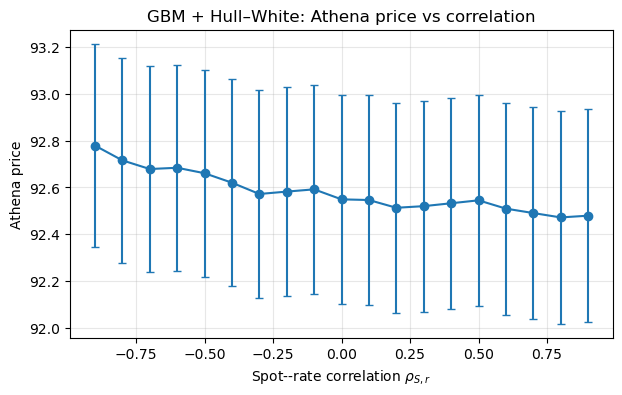

In [ ]:
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for parent in [p] + list(p.parents):
        if (parent / "pyproject.toml").is_file() and (parent / "src" / "pricer").is_dir():
            return parent
    raise FileNotFoundError(
        "Could not find repo root containing pyproject.toml and src/pricer.\n"
        f"Start was: {start}\n"
        "Move the notebook inside the repo, or set ROOT_V5 manually."
    )

repo_root = find_repo_root(Path.cwd())
src_path = str(repo_root / "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)


for k in list(sys.modules.keys()):
    if k == "pricer" or k.startswith("pricer."):
        del sys.modules[k]

import os, sys
from pathlib import Path

import pricer
import pricer.core.models as models_mod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pricer.core.models import Model
from pricer.core.pricing import MonteCarloPricer
from pricer.core.observation import ObservationFrequency
from pricer.core.products import AutocallAthenaProduct

product = AutocallAthenaProduct(
    nominal=100.0,
    strike=100.0,
    coupon_per_year=0.04,
    maturity_years_=5.0,
    obs_freq=ObservationFrequency.ANNUAL,
    call_barrier=1.0,
    protection_barrier=0.7,
    steps_per_year=52,
    with_memory=False,
)

pricer = MonteCarloPricer(antithetic=True, control_variate=True)

RHO_GRID = np.linspace(-0.9, 0.9, 19)
rows = []

for rho in RHO_GRID:
    model = Model(
        spot_process="GBM",
        rate_process="HULLWHITE",
        vol_process="FLAT",
        s0=100.0,
        sigma=0.20,
        r0=0.02,
        a=0.10,
        b=0.02,
        sigma_r=0.01,
        rho_sr=float(rho),
        rho_vr=0.0,
        steps_per_year=52,
        n_paths=5_000,
        seed=12345,   # CRN across rho
    )

    price, se = pricer.price(product, model)
    rows.append({"rho_sr": float(rho), "price": float(price), "se": float(se)})

df_corr = pd.DataFrame(rows)
display(df_corr)

plt.figure(figsize=(7,4))
plt.errorbar(df_corr["rho_sr"], df_corr["price"], yerr=1.96*df_corr["se"], marker="o", capsize=3)
plt.xlabel(r"Spot--rate correlation $\rho_{S,r}$")
plt.ylabel("Athena price")
plt.title("GBM + Hull–White: Athena price vs correlation")
plt.grid(True, alpha=0.3)
plt.show()


,rho_sr,athena_price,athena_se,athena_rel_pct,athena_dRel_drho_pct,phoenix_price,phoenix_se,phoenix_rel_pct,phoenix_dRel_drho_pct
0,-0.9,92.779074,0.222260,0.248492,-0.682332,95.632974,0.216684,0.294351,-0.655103
1,-0.8,92.715924,0.223516,0.180259,-0.541765,95.570508,0.218043,0.228841,-0.526763
2,-0.7,92.678794,0.224504,0.140139,-0.171493,95.532518,0.219288,0.188999,-0.206129
3,-0.6,92.684181,0.224997,0.145960,-0.096957,95.531198,0.220161,0.187615,-0.127654
4,-0.5,92.660847,0.225695,0.120748,-0.344939,95.508174,0.221032,0.163468,-0.405376
5,-0.4,92.620334,0.226509,0.076973,-0.479799,95.453891,0.222065,0.106540,-0.538428
6,-0.3,92.572037,0.227157,0.024788,-0.205889,95.405493,0.222892,0.055782,-0.275300
7,-0.2,92.582224,0.227575,0.035795,0.107296,95.401390,0.223428,0.051480,-0.018323
8,-0.1,92.591897,0.228076,0.046247,-0.178973,95.401999,0.224031,0.052118,-0.257399
9,0.0,92.549096,0.228708,0.000000,-0.246584,95.352303,0.224676,0.000000,-0.308245


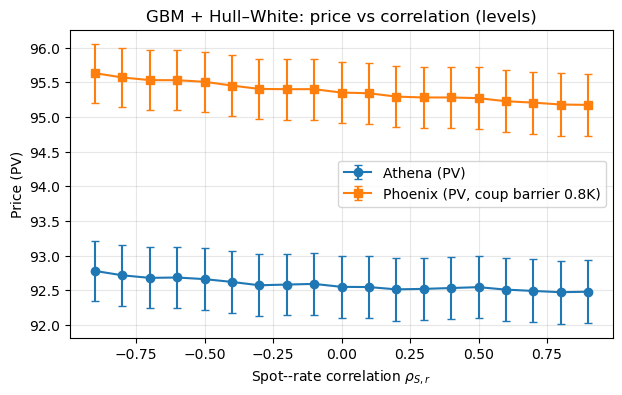

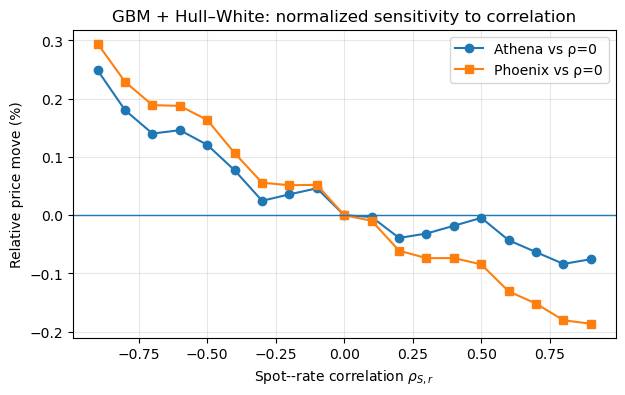

In [4]:
#import os, sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for parent in [p] + list(p.parents):
        if (parent / "pyproject.toml").is_file() and (parent / "src" / "pricer").is_dir():
            return parent
    raise FileNotFoundError(
        "Could not find repo root containing pyproject.toml and src/pricer.\n"
        f"Start was: {start}\n"
        "Move the notebook inside the repo, or set ROOT_V5 manually."
    )

repo_root = find_repo_root(Path.cwd())
src_path = str(repo_root / "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)


for k in list(sys.modules.keys()):
    if k == "pricer" or k.startswith("pricer."):
        del sys.modules[k]

import pricer
import pricer.core.models as models_mod




idx0 = (df_corr["rho_sr"].abs()).idxmin()
rho0 = float(df_corr.loc[idx0, "rho_sr"])

P0_a = float(df_corr.loc[idx0, "athena_price"])
P0_p = float(df_corr.loc[idx0, "phoenix_price"])


df_corr["athena_rel_pct"]  = 100.0 * (df_corr["athena_price"] / P0_a - 1.0)
df_corr["phoenix_rel_pct"] = 100.0 * (df_corr["phoenix_price"] / P0_p - 1.0)


df_corr["athena_dP_drho"]  = np.gradient(df_corr["athena_price"].values,  df_corr["rho_sr"].values)
df_corr["phoenix_dP_drho"] = np.gradient(df_corr["phoenix_price"].values, df_corr["rho_sr"].values)


df_corr["athena_dRel_drho_pct"]  = 100.0 * df_corr["athena_dP_drho"] / P0_a
df_corr["phoenix_dRel_drho_pct"] = 100.0 * df_corr["phoenix_dP_drho"] / P0_p

display(df_corr[[
    "rho_sr",
    "athena_price", "athena_se", "athena_rel_pct", "athena_dRel_drho_pct",
    "phoenix_price","phoenix_se","phoenix_rel_pct","phoenix_dRel_drho_pct",
]])


plt.figure(figsize=(7,4))
plt.errorbar(df_corr["rho_sr"], df_corr["athena_price"], yerr=1.96*df_corr["athena_se"],
             marker="o", capsize=3, label="Athena (PV)")
plt.errorbar(df_corr["rho_sr"], df_corr["phoenix_price"], yerr=1.96*df_corr["phoenix_se"],
             marker="s", capsize=3, label="Phoenix (PV, coup barrier 0.8K)")
plt.xlabel(r"Spot--rate correlation $\rho_{S,r}$")
plt.ylabel("Price (PV)")
plt.title("GBM + Hull–White: price vs correlation (levels)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(7,4))
plt.plot(df_corr["rho_sr"], df_corr["athena_rel_pct"], marker="o", label=f"Athena vs ρ={rho0:g}")
plt.plot(df_corr["rho_sr"], df_corr["phoenix_rel_pct"], marker="s", label=f"Phoenix vs ρ={rho0:g}")
plt.axhline(0.0, linewidth=1)
plt.xlabel(r"Spot--rate correlation $\rho_{S,r}$")
plt.ylabel("Relative price move (%)")
plt.title("GBM + Hull–White: normalized sensitivity to correlation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


model,GBM + HW,Heston + HW,rBergomi + HW
rho_sr,,,
-0.7,92.595385,93.841964,92.723756
-0.6,92.550197,93.869505,92.698398
-0.5,92.523063,93.848653,92.665323
-0.4,92.504133,93.837244,92.658355
-0.3,92.489066,93.816932,92.657344
-0.2,92.468235,93.794224,92.658962
-0.1,92.448149,93.788888,92.644875
0.0,92.427865,93.791957,92.631434
0.1,92.412478,93.764670,92.608781


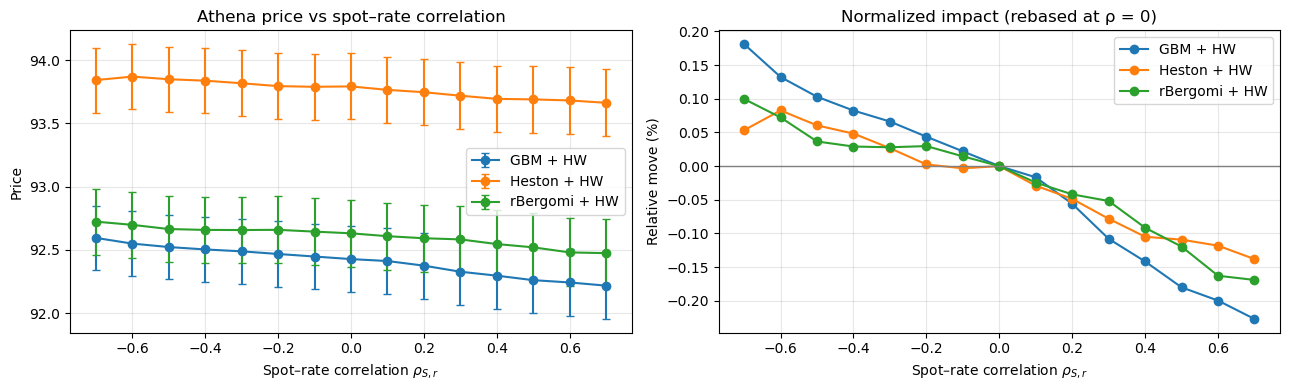

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pricer.core.models import Model
from pricer.core.pricing import MonteCarloPricer
from pricer.core.observation import ObservationFrequency
from pricer.core.products import AutocallAthenaProduct


athena = AutocallAthenaProduct(
    nominal=100.0,
    strike=100.0,
    coupon_per_year=0.04,
    maturity_years_=5.0,
    obs_freq=ObservationFrequency.ANNUAL,
    call_barrier=1.0,
    protection_barrier=0.7,
    steps_per_year=52,
    with_memory=False,
)


pricer = MonteCarloPricer(antithetic=True, control_variate=True)

def price_with_df_alias(product, model, antithetic=True):
    paths = model.simulate_paths(maturity_years=product.maturity_years, antithetic=antithetic)
    if "df" not in paths and "D" in paths:
        paths["df"] = paths["D"]
    payoffs, dfs = product.payoff_from_paths(paths)
    discounted = payoffs * dfs
    price = discounted.mean()
    se = discounted.std(ddof=1) / np.sqrt(discounted.shape[0])
    return float(price), float(se)

# ----------------------------
# Feasible rho grid (PD constraint for 3x3 corr with rho_vr=0)
# rBergomi uses rough_rho as rho_sv, so with -0.7 => max ~ 0.714
# ----------------------------
RHO_GRID = np.linspace(-0.70, 0.70, 15)

MODEL_SPECS = [
    dict(name="GBM + HW",      spot_process="GBM",    vol_process="FLAT"),
    dict(name="Heston + HW",   spot_process="HESTON", vol_process="HESTON"),
    dict(name="rBergomi + HW", spot_process="GBM",    vol_process="RBERGOMI"),
]

rows = []
for rho in RHO_GRID:
    for spec in MODEL_SPECS:
        kwargs = dict(
            spot_process=spec["spot_process"],
            rate_process="HULLWHITE",
            vol_process=spec["vol_process"],
            s0=100.0,
            r0=0.02,
            a=0.10,
            b=0.02,
            sigma_r=0.01,
            rho_sr=float(rho),
            rho_vr=0.0,          # isolate spot-rate channel
            steps_per_year=52,
            n_paths=20_000,
            seed=12345,
        )

        if spec["name"] == "GBM + HW":
            kwargs.update(sigma=0.20)

        elif spec["name"] == "Heston + HW":
            # TODO: replace with your calibrated params
            kwargs.update(v0=0.04, kappa=2.0, theta=0.04, xi=0.5, rho_sv=-0.6)

        elif spec["name"] == "rBergomi + HW":
            # TODO: replace with your calibrated params (+ xi0 if available)
            kwargs.update(rough_H=0.10, rough_nu=0.30, rough_rho=-0.7)
            # kwargs.update(xi0_times=xi0_times, xi0_values=xi0_values)

        model = Model(**kwargs)
        price, se = price_with_df_alias(athena, model, antithetic=pricer.antithetic)

        rows.append({"model": spec["name"], "rho_sr": float(rho), "price": price, "se": se})

df = pd.DataFrame(rows)

# Normalize at rho=0 per model
df["rel_pct"] = np.nan
for m in df["model"].unique():
    ref = df.loc[(df["model"] == m) & (np.isclose(df["rho_sr"], 0.0)), "price"].values[0]
    df.loc[df["model"] == m, "rel_pct"] = 100.0 * (df.loc[df["model"] == m, "price"] / ref - 1.0)

display(df.pivot(index="rho_sr", columns="model", values="price"))

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for m in df["model"].unique():
    sub = df[df["model"] == m].sort_values("rho_sr")
    axes[0].errorbar(sub["rho_sr"], sub["price"], yerr=1.96*sub["se"],
                     marker="o", capsize=3, label=m)

axes[0].set_title("Athena price vs spot–rate correlation")
axes[0].set_xlabel(r"Spot–rate correlation $\rho_{S,r}$")
axes[0].set_ylabel("Price")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for m in df["model"].unique():
    sub = df[df["model"] == m].sort_values("rho_sr")
    axes[1].plot(sub["rho_sr"], sub["rel_pct"], marker="o", label=m)

axes[1].axhline(0.0, color="gray", lw=1)
axes[1].set_title("Normalized impact (rebased at ρ = 0)")
axes[1].set_xlabel(r"Spot–rate correlation $\rho_{S,r}$")
axes[1].set_ylabel("Relative move (%)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()





## Recall probability



Model prices (mean discounted payoff):
  GBM + HW      : 92.427865
  Heston + HW   : 93.791957
  rBergomi + HW : 92.631434


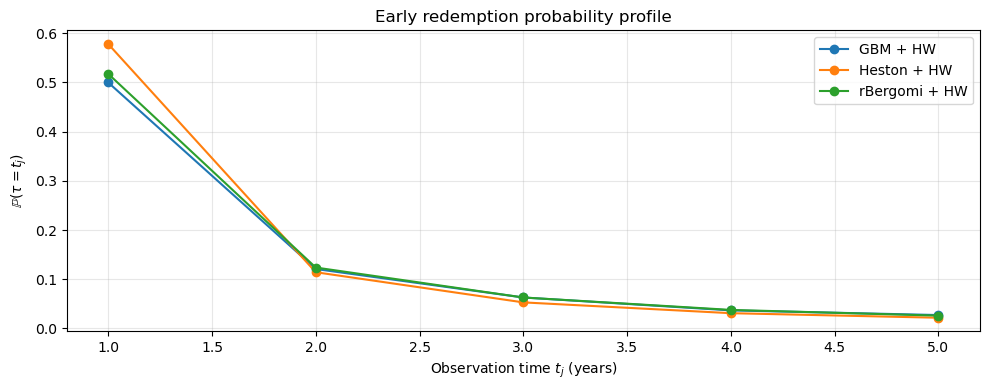

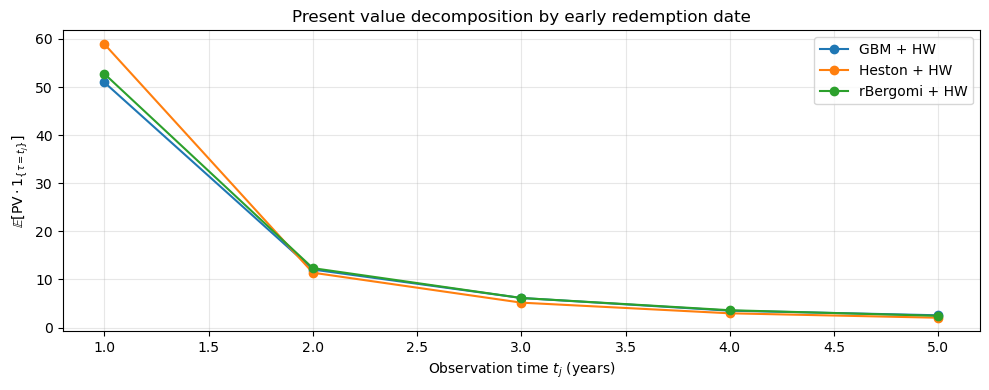

,model,P(tau=inf),PV contrib (inf)
0,GBM + HW,0.25220,17.166342
1,Heston + HW,0.20165,13.238840
2,rBergomi + HW,0.23190,15.307778


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pricer.core.models import Model
from pricer.core.pricing import MonteCarloPricer
from pricer.core.observation import ObservationFrequency
from pricer.core.products import AutocallAthenaProduct


athena = AutocallAthenaProduct(
    nominal=100.0,
    strike=100.0,
    coupon_per_year=0.04,
    maturity_years_=5.0,
    obs_freq=ObservationFrequency.ANNUAL,
    call_barrier=1.0,
    protection_barrier=0.7,
    steps_per_year=52,      # simulation grid
    with_memory=False,
)

pricer = MonteCarloPricer(antithetic=True, control_variate=True)


# ----------------------------
#obs schedule + stopping time tau (first call)
# ----------------------------
def _obs_times_and_indices(product, steps_per_year: int):
    """
    Returns:
      t_obs: array of observation times in years, length m
      idx_obs: corresponding indices on the simulation grid
    """
    T = float(product.maturity_years)
    if product.obs_freq == ObservationFrequency.ANNUAL:
        obs_per_year = 1
    elif product.obs_freq == ObservationFrequency.SEMIANNUAL:
        obs_per_year = 2
    elif product.obs_freq == ObservationFrequency.QUARTERLY:
        obs_per_year = 4
    elif product.obs_freq == ObservationFrequency.MONTHLY:
        obs_per_year = 12
    else:
        raise ValueError(f"Unsupported obs_freq: {product.obs_freq}")

    m = int(round(T * obs_per_year))
    t_obs = np.arange(1, m + 1) / obs_per_year

    
    idx_obs = np.round(t_obs * steps_per_year).astype(int)
    return t_obs, idx_obs


def _first_call_index_from_paths(product, paths, steps_per_year: int):
    """
    Compute tau (first call date index j) from simulated spot paths.

    Returns:
      tau_j: int array of shape (n_paths,)
             tau_j = 0..m-1 for first call at t_obs[j]
             tau_j = -1 for no call (tau = infinity)
    """
    
    S = None
    for key in ["S", "spot", "spots"]:
        if key in paths:
            S = paths[key]
            break
    if S is None:
        raise KeyError(f"Could not find spot paths in keys={list(paths.keys())}")

 
    S = np.asarray(S)
    if S.ndim != 2:
        raise ValueError(f"Unexpected S shape {S.shape}, expected 2D (n_paths, n_steps+1)")

    t_obs, idx_obs = _obs_times_and_indices(product, steps_per_year)


    barrier = float(product.call_barrier) * float(product.strike)

    S_obs = S[:, idx_obs]               # (n_paths, m)
    hit = (S_obs >= barrier)            # (n_paths, m)

    # first hit per row (if any)
    any_hit = hit.any(axis=1)
    first = np.argmax(hit, axis=1)      # returns 0 if all False, so mask with any_hit

    tau_j = np.full(S.shape[0], -1, dtype=int)
    tau_j[any_hit] = first[any_hit]
    return tau_j, t_obs



def redemption_profile(product, model: Model, pricer: MonteCarloPricer):
    """
    Returns a dataframe with:
      - t_obs
      - P_tau_tj
      - PV_contrib_tj
    plus a final row for tau=inf (no call)
    """
    paths = model.simulate_paths(maturity_years=product.maturity_years, antithetic=pricer.antithetic)
    if ("df" not in paths) and ("D" in paths):
        paths["df"] = paths["D"]

    payoffs, dfs = product.payoff_from_paths(paths)
    discounted = np.asarray(payoffs) * np.asarray(dfs) 

    tau_j, t_obs = _first_call_index_from_paths(product, paths, steps_per_year=model.steps_per_year)
    n = discounted.shape[0]
    m = len(t_obs)

    rows = []
    for j in range(m):
        mask = (tau_j == j)
        p = mask.mean()
        pv = discounted[mask].mean() * p if mask.any() else 0.0
        # Note: pv = E[disc payoff * 1_{tau=j}] = mean(discounted[mask]) * P(mask)
        rows.append({"t": float(t_obs[j]), "tau": f"t{j+1}", "prob": float(p), "pv_contrib": float(pv)})

    # No call:
    mask_inf = (tau_j == -1)
    p_inf = mask_inf.mean()
    pv_inf = discounted[mask_inf].mean() * p_inf if mask_inf.any() else 0.0
    rows.append({"t": float(product.maturity_years), "tau": "inf", "prob": float(p_inf), "pv_contrib": float(pv_inf)})

    df = pd.DataFrame(rows)
    # sanity checks
    df["prob_cum"] = df["prob"].cumsum()
    return df, float(discounted.mean())



RHO_SR = 0.0  
N_PATHS = 20_000
STEPS = 52

model_specs = [
    ("GBM + HW", dict(spot_process="GBM",   vol_process="FLAT")),
    ("Heston + HW", dict(spot_process="HESTON", vol_process="HESTON")),
    ("rBergomi + HW", dict(spot_process="GBM", vol_process="RBERGOMI")),
]

results = {}
prices = {}

for name, spec in model_specs:
    kwargs = dict(
        spot_process=spec["spot_process"],
        rate_process="HULLWHITE",
        vol_process=spec["vol_process"],
        s0=100.0,
        r0=0.02,
        a=0.10,
        b=0.02,
        sigma_r=0.01,
        rho_sr=float(RHO_SR),
        rho_vr=0.0,                 
        steps_per_year=STEPS,
        n_paths=N_PATHS,
        seed=12345,
    )

    if name == "GBM + HW":
        kwargs.update(sigma=0.20)

    elif name == "Heston + HW":
        kwargs.update(v0=0.04, kappa=2.0, theta=0.04, xi=0.5, rho_sv=-0.6)

    elif name == "rBergomi + HW":
        kwargs.update(rough_H=0.10, rough_nu=0.30, rough_rho=-0.7)
        

    model = Model(**kwargs)
    df_prof, price = redemption_profile(athena, model, pricer)
    results[name] = df_prof
    prices[name] = price

print("Model prices (mean discounted payoff):")
for k, v in prices.items():
    print(f"  {k:14s}: {v:.6f}")



plt.figure(figsize=(10, 4))
for name, df_prof in results.items():
    df_plot = df_prof[df_prof["tau"] != "inf"]
    plt.plot(df_plot["t"], df_plot["prob"], marker="o", label=name)

plt.xlabel("Observation time $t_j$ (years)")
plt.ylabel(r"$\mathbb{P}(\tau=t_j)$")
plt.title("Early redemption probability profile")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 4))
for name, df_prof in results.items():
    df_plot = df_prof[df_prof["tau"] != "inf"]
    plt.plot(df_plot["t"], df_plot["pv_contrib"], marker="o", label=name)

plt.xlabel("Observation time $t_j$ (years)")
plt.ylabel(r"$\mathbb{E}[\mathrm{PV}\cdot 1_{\{\tau=t_j\}}]$")
plt.title("Present value decomposition by early redemption date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



summary_rows = []
for name, df_prof in results.items():
    p_inf = float(df_prof.loc[df_prof["tau"] == "inf", "prob"].values[0])
    pv_inf = float(df_prof.loc[df_prof["tau"] == "inf", "pv_contrib"].values[0])
    summary_rows.append({"model": name, "P(tau=inf)": p_inf, "PV contrib (inf)": pv_inf})

summary = pd.DataFrame(summary_rows)
display(summary)


## Greeks properly


,Price,SE,Delta,Gamma,Vega(1% knob),Theta(dV/dT),Vanna(1%),Volga(1%^2),VolKnob
Model,,,,,,,,,
GBM + HW,92.418525,0.115667,0.491734,0.103259,-13.231983,-10.200412,0.537817,-28.276094,sigma
Heston + HW,93.800709,0.114937,0.496180,-0.265969,-1.249272,6.211642,0.541232,-92.815361,v0
rBergomi + HW,92.602625,0.116138,0.452349,-0.205895,0.741961,3.949969,0.256317,-106.219682,rough_nu


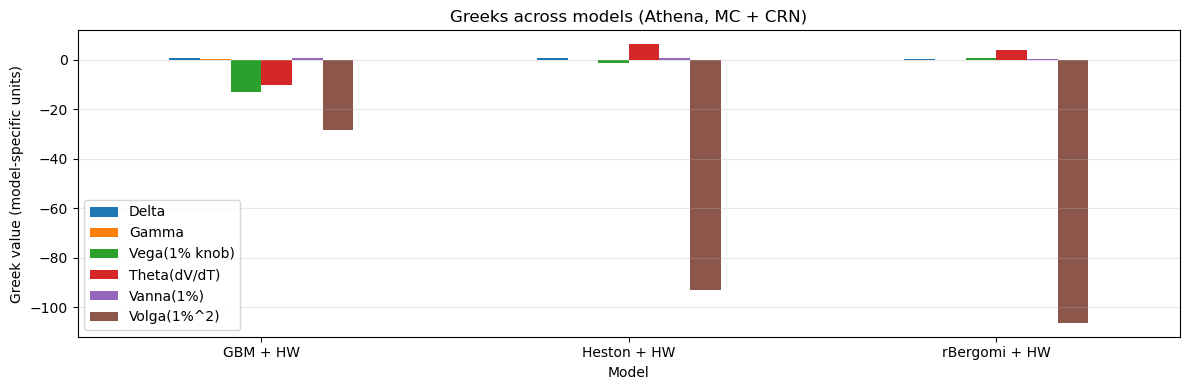

Volatility knob used per model:
Model
GBM + HW            sigma
Heston + HW            v0
rBergomi + HW    rough_nu
Name: VolKnob, dtype: object


In [ ]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pricer.core.models import Model
from pricer.core.pricing import MonteCarloPricer
from pricer.core.observation import ObservationFrequency
from pricer.core.products import AutocallAthenaProduct

def make_athena(T=5.0):
    return AutocallAthenaProduct(
        nominal=100.0,
        strike=100.0,
        coupon_per_year=0.04,
        maturity_years_=float(T),
        obs_freq=ObservationFrequency.ANNUAL,
        call_barrier=1.0,
        protection_barrier=0.7,
        steps_per_year=52,
        with_memory=False,
    )


def make_model(name: str, rho_sr=0.0, n_paths=20_000, steps=52, seed=12345):
    common = dict(
        rate_process="HULLWHITE",
        s0=100.0,
        r0=0.02,
        a=0.10,
        b=0.02,
        sigma_r=0.01,
        rho_sr=float(rho_sr),
        rho_vr=0.0,               
        steps_per_year=int(steps),
        n_paths=int(n_paths),
        seed=int(seed),
    )

    name = name.lower()
    if name == "gbm_hw":
        return Model(spot_process="GBM", vol_process="FLAT", sigma=0.20, **common)

    if name == "heston_hw":
        return Model(
            spot_process="HESTON", vol_process="HESTON",
            v0=0.04, kappa=2.0, theta=0.04, xi=0.5, rho_sv=-0.6,
            **common
        )

    if name == "rbergomi_hw":
        
        return Model(
            spot_process="GBM", vol_process="RBERGOMI",
            rough_H=0.10, rough_nu=0.30, rough_rho=-0.7,
            **common
        )

    raise ValueError(f"Unknown model name: {name}")


pricer = MonteCarloPricer(antithetic=True, control_variate=True)

def price(model: Model, product, rng_state=None):
    return pricer.price(product, model, rng_state=rng_state)  # returns (price, se)


def bump_spot(model: Model, rel_bump: float):
    m = copy.deepcopy(model)
    m.s0 = float(model.s0) * (1.0 + rel_bump)
    return m

def bump_vol_knob(model: Model, rel_bump: float):
    """
    Returns bumped model and a string describing what was bumped.
    Priority for rBergomi: bump xi0_values level if present; else bump rough_nu.
    """
    m = copy.deepcopy(model)

    # GBM: bump sigma
    if getattr(model, "vol_process", "").upper() == "FLAT":
        m.sigma = float(model.sigma) * (1.0 + rel_bump)
        return m, "sigma"

    # Heston: bump v0 (variance-level proxy)
    if getattr(model, "vol_process", "").upper() == "HESTON":
        m.v0 = float(model.v0) * (1.0 + rel_bump)
        return m, "v0"

    # rBergomi: bump xi0 curve level if available; else rough_nu
    if getattr(model, "vol_process", "").upper() == "RBERGOMI":
        if hasattr(model, "xi0_values") and model.xi0_values is not None:
            m.xi0_values = np.asarray(model.xi0_values, dtype=float) * (1.0 + rel_bump)
            return m, "xi0_level"
        # fallback
        if hasattr(model, "rough_nu"):
            m.rough_nu = float(model.rough_nu) * (1.0 + rel_bump)
            return m, "rough_nu"

    raise ValueError("No recognized volatility knob for this model.")


def greeks_for_model(model: Model, product, hs=0.005, hv=0.01, dt=1/252):
    """
    hs: relative spot bump for Delta/Gamma
    hv: relative vol knob bump for Vega/Vanna/Volga
    dt: year bump for Theta (central difference on maturity)
    """

    rng_state = copy.deepcopy(model.rng.bit_generator.state)

    V0, se0 = price(model, product, rng_state=rng_state)

    
    Vm, _ = price(bump_spot(model, -hs), product, rng_state=rng_state)
    Vp, _ = price(bump_spot(model, +hs), product, rng_state=rng_state)
    S0 = float(model.s0)
    hS = hs * S0
    delta = (Vp - Vm) / (2.0 * hS)
    gamma = (Vp - 2.0 * V0 + Vm) / (hS * hS)

    # Vega, Volga (vol knob)
    m_vm, knob = bump_vol_knob(model, -hv)
    m_vp, _    = bump_vol_knob(model, +hv)
    Vvm, _ = price(m_vm, product, rng_state=rng_state)
    Vvp, _ = price(m_vp, product, rng_state=rng_state)
    vega  = (Vvp - Vvm) / (2.0 * hv)              # per +1.0 = +100% of knob; interpret as "per 1%": multiply by 0.01 if needed
    volga = (Vvp - 2.0 * V0 + Vvm) / (hv * hv)

    # Vanna: cross derivative spot-vol
   
    m_sp = bump_spot(model, +hs)
    m_sm = bump_spot(model, -hs)

    m_sp_vp, _ = bump_vol_knob(m_sp, +hv)
    m_sp_vm, _ = bump_vol_knob(m_sp, -hv)
    m_sm_vp, _ = bump_vol_knob(m_sm, +hv)
    m_sm_vm, _ = bump_vol_knob(m_sm, -hv)

    V_sp_vp, _ = price(m_sp_vp, product, rng_state=rng_state)
    V_sp_vm, _ = price(m_sp_vm, product, rng_state=rng_state)
    V_sm_vp, _ = price(m_sm_vp, product, rng_state=rng_state)
    V_sm_vm, _ = price(m_sm_vm, product, rng_state=rng_state)

    vanna = (V_sp_vp - V_sp_vm - V_sm_vp + V_sm_vm) / (4.0 * hS * hv)

    # Theta: central difference on maturity (approx)
    # Rebuild product with T +/- dt (keeps all other terms same)
        # Theta: backward difference in maturity (avoids out-of-bounds at T+dt)
    T0 = float(product.maturity_years)

    # choose dt aligned with model time-grid (important!)
    dt = 1.0 / float(model.steps_per_year)  # one simulation step in years

    prod_m = make_athena(T=max(1e-6, T0 - dt))

    V_Tm, _ = price(model, prod_m, rng_state=rng_state)

    # dV/dT approx; "calendar theta" is typically -dV/dt
    theta_dVdT = (V0 - V_Tm) / dt


    # Scale vega-family to "per +1%" if you want report units:
    # right now vega is per +hv (e.g. 1%) because hv=0.01
    # so as written vega is already "per 1% bump" (same for vanna/volga in hv units).
    return {
        "Price": V0,
        "SE": se0,
        "Delta": delta,
        "Gamma": gamma,
        "Vega(1% knob)": vega,
        "Theta(dV/dT)": theta_dVdT,
        "Vanna(1%)": vanna,
        "Volga(1%^2)": volga,
        "VolKnob": knob,
    }


product = make_athena(T=5.0)

models = {
    "GBM + HW": make_model("gbm_hw"),
    "Heston + HW": make_model("heston_hw"),
    "rBergomi + HW": make_model("rbergomi_hw"),
}

rows = []
for name, m in models.items():
    out = greeks_for_model(m, product, hs=0.005, hv=0.01)
    out["Model"] = name
    rows.append(out)

df = pd.DataFrame(rows).set_index("Model")
display(df)


plot_cols = ["Delta","Gamma","Vega(1% knob)","Theta(dV/dT)","Vanna(1%)","Volga(1%^2)"]
ax = df[plot_cols].plot(kind="bar", figsize=(12,4), rot=0)
ax.set_title("Greeks across models (Athena, MC + CRN)")
ax.set_ylabel("Greek value (model-specific units)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Volatility knob used per model:")
print(df["VolKnob"])


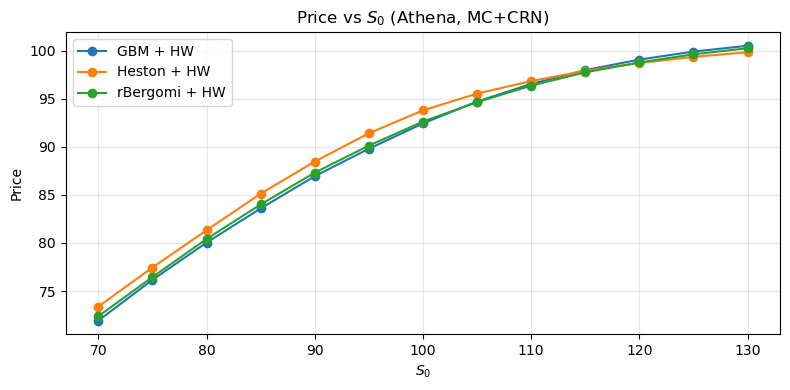

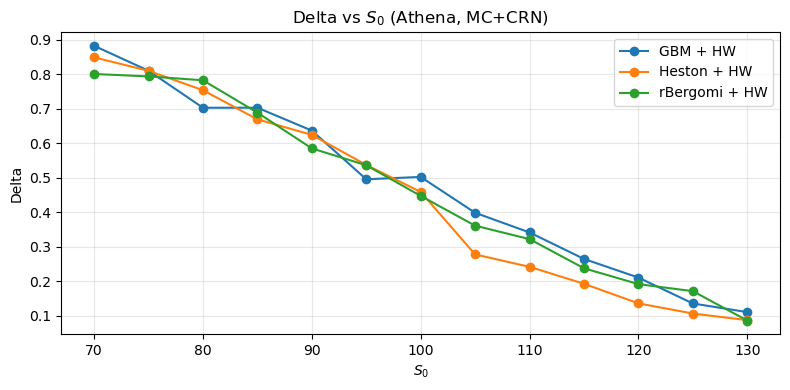

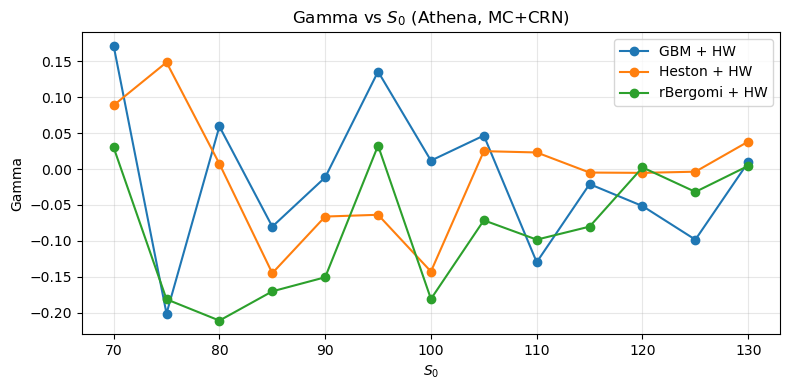

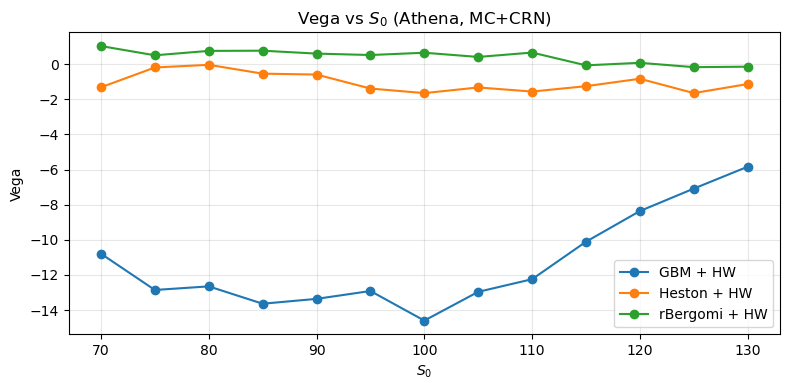

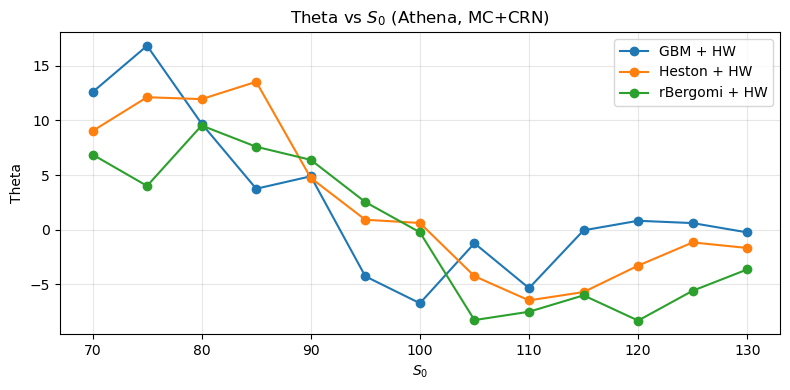

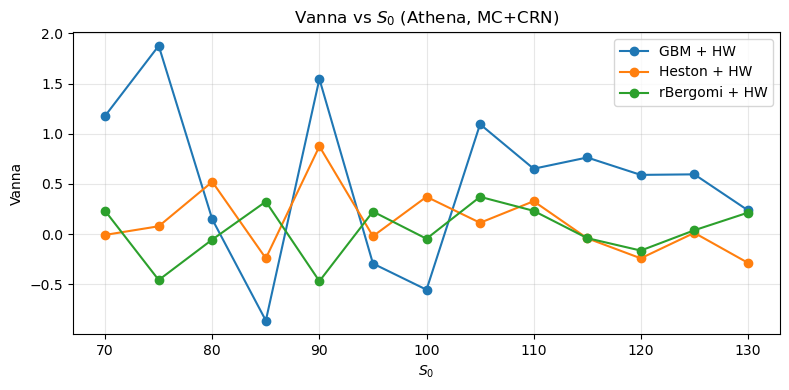

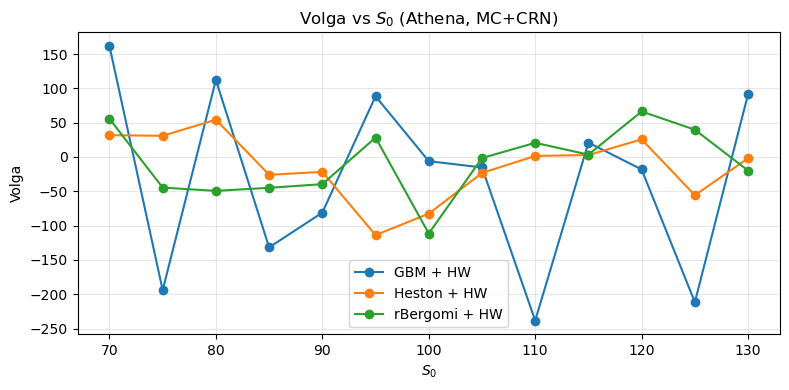

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy


def greeks_for_model(model, product, hs=0.005, hv=0.01):
    rng_state = copy.deepcopy(model.rng.bit_generator.state)
    V0, se0 = pricer.price(product, model, rng_state=rng_state)

  
    Vm, _ = pricer.price(product, bump_spot(model, -hs), rng_state=rng_state)
    Vp, _ = pricer.price(product, bump_spot(model, +hs), rng_state=rng_state)
    S0 = float(model.s0)
    hS = hs * S0
    delta = (Vp - Vm) / (2.0 * hS)
    gamma = (Vp - 2.0 * V0 + Vm) / (hS * hS)

    
    m_vm, knob = bump_vol_knob(model, -hv)
    m_vp, _    = bump_vol_knob(model, +hv)
    Vvm, _ = pricer.price(product, m_vm, rng_state=rng_state)
    Vvp, _ = pricer.price(product, m_vp, rng_state=rng_state)
    vega  = (Vvp - Vvm) / (2.0 * hv)
    volga = (Vvp - 2.0 * V0 + Vvm) / (hv * hv)

   
    m_sp = bump_spot(model, +hs)
    m_sm = bump_spot(model, -hs)
    m_sp_vp, _ = bump_vol_knob(m_sp, +hv)
    m_sp_vm, _ = bump_vol_knob(m_sp, -hv)
    m_sm_vp, _ = bump_vol_knob(m_sm, +hv)
    m_sm_vm, _ = bump_vol_knob(m_sm, -hv)

    V_sp_vp, _ = pricer.price(product, m_sp_vp, rng_state=rng_state)
    V_sp_vm, _ = pricer.price(product, m_sp_vm, rng_state=rng_state)
    V_sm_vp, _ = pricer.price(product, m_sm_vp, rng_state=rng_state)
    V_sm_vm, _ = pricer.price(product, m_sm_vm, rng_state=rng_state)
    vanna = (V_sp_vp - V_sp_vm - V_sm_vp + V_sm_vm) / (4.0 * hS * hv)

    # Theta (backward, one grid step)
    dt = 1.0 / float(model.steps_per_year)
    T0 = float(product.maturity_years)
    prod_m = make_athena(T=max(1e-6, T0 - dt))
    V_Tm, _ = pricer.price(prod_m, model, rng_state=rng_state)
    theta = (V0 - V_Tm) / dt  # dV/dT approx

    return {"Price": V0, "Delta": delta, "Gamma": gamma,
            "Vega": vega, "Theta": theta, "Vanna": vanna, "Volga": volga}


S_GRID = np.linspace(70, 130, 13)

model_builders = {
    "GBM + HW":      lambda s: make_model("gbm_hw",    n_paths=30_000, steps=52, seed=12345, rho_sr=0.0) if False else None,
    "Heston + HW":   lambda s: make_model("heston_hw", n_paths=30_000, steps=52, seed=12345, rho_sr=0.0) if False else None,
    "rBergomi + HW": lambda s: make_model("rbergomi_hw", n_paths=30_000, steps=52, seed=12345, rho_sr=0.0) if False else None,
}


base_models = {
    "GBM + HW": make_model("gbm_hw", n_paths=30_000, steps=52, seed=12345, rho_sr=0.0),
    "Heston + HW": make_model("heston_hw", n_paths=30_000, steps=52, seed=12345, rho_sr=0.0),
    "rBergomi + HW": make_model("rbergomi_hw", n_paths=30_000, steps=52, seed=12345, rho_sr=0.0),
}

product = make_athena(T=5.0)

rows = []
for S0 in S_GRID:
    for name, base in base_models.items():
        m = copy.deepcopy(base)
        m.s0 = float(S0)
        out = greeks_for_model(m, product, hs=0.005, hv=0.01)
        out["Model"] = name
        out["S0"] = float(S0)
        rows.append(out)

dfS = pd.DataFrame(rows)


greeks = ["Price","Delta","Gamma","Vega","Theta","Vanna","Volga"]
for g in greeks:
    plt.figure(figsize=(8,4))
    for name in dfS["Model"].unique():
        sub = dfS[dfS["Model"] == name].sort_values("S0")
        plt.plot(sub["S0"], sub[g], marker="o", label=name)
    plt.xlabel("$S_0$")
    plt.ylabel(g)
    plt.title(f"{g} vs $S_0$ (Athena, MC+CRN)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


Model,GBM + HW,Heston + HW,rBergomi + HW
T,,,
1.0,100.470798,99.117494,100.106278
2.0,96.956902,96.358064,96.490324
3.0,94.511417,95.060378,94.548355
4.0,93.266942,94.204800,93.330029
5.0,92.418525,93.800709,92.602625


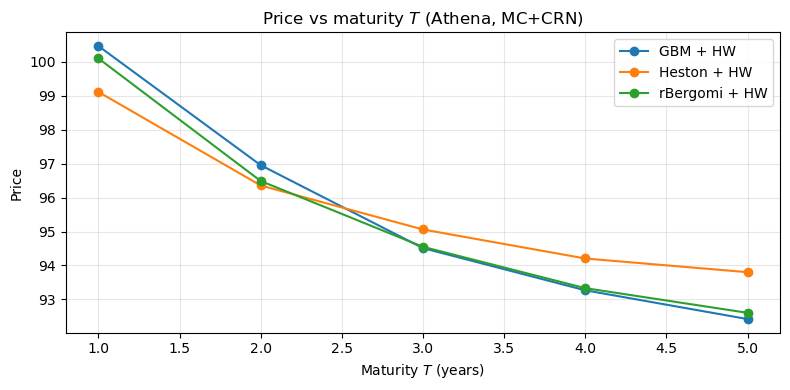

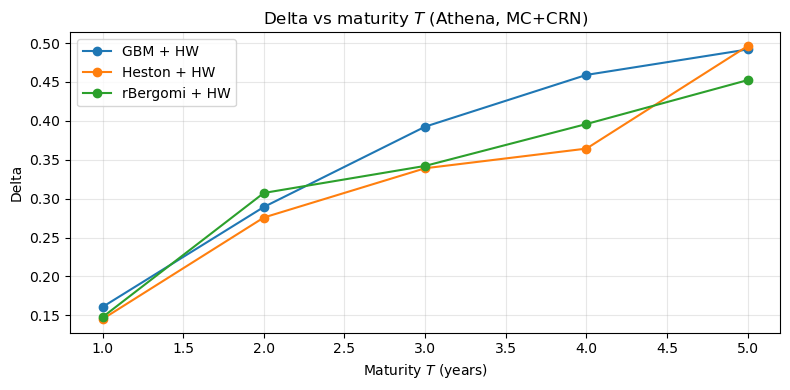

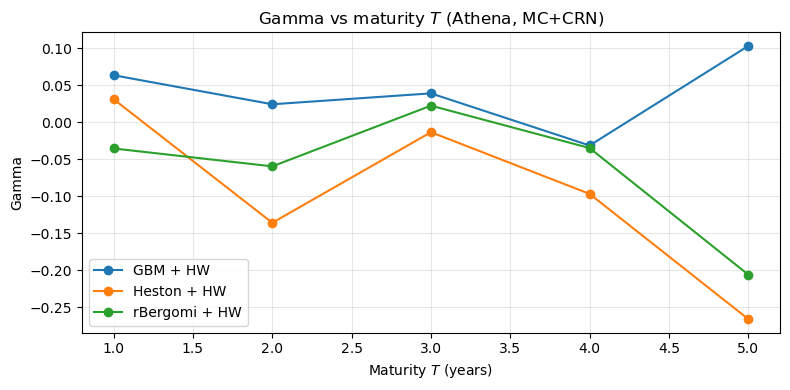

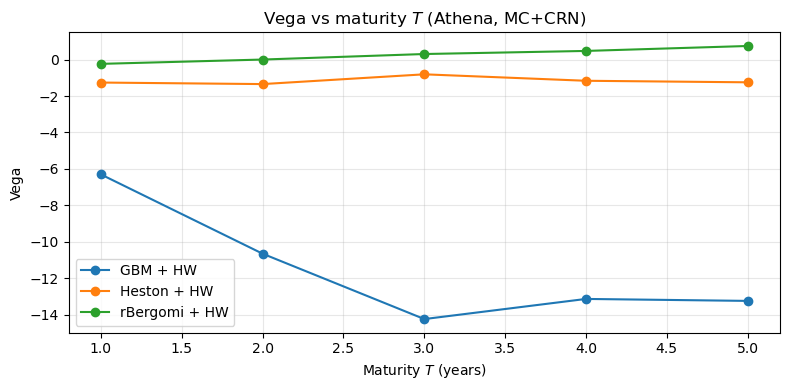

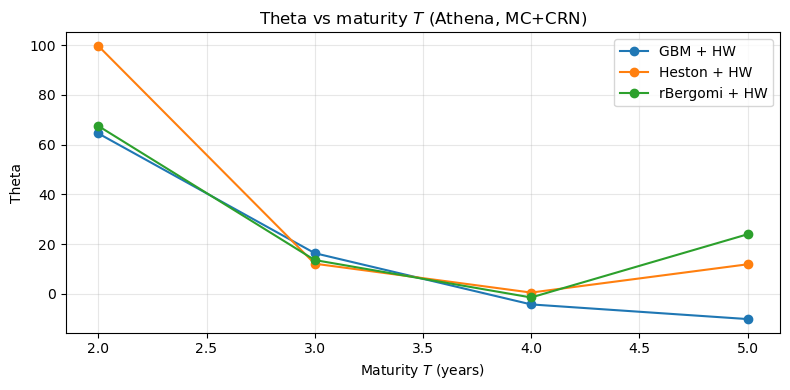

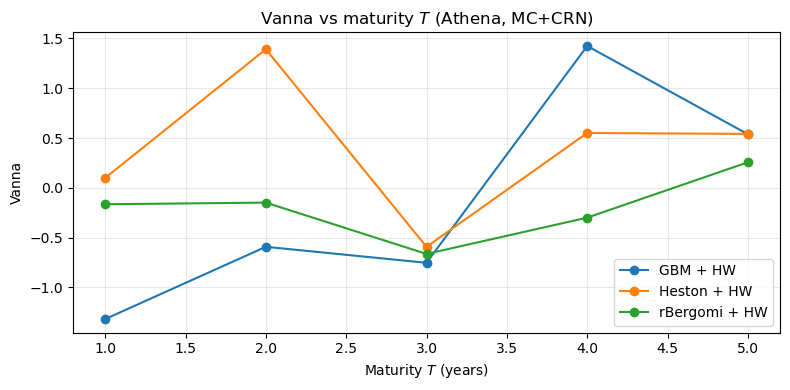

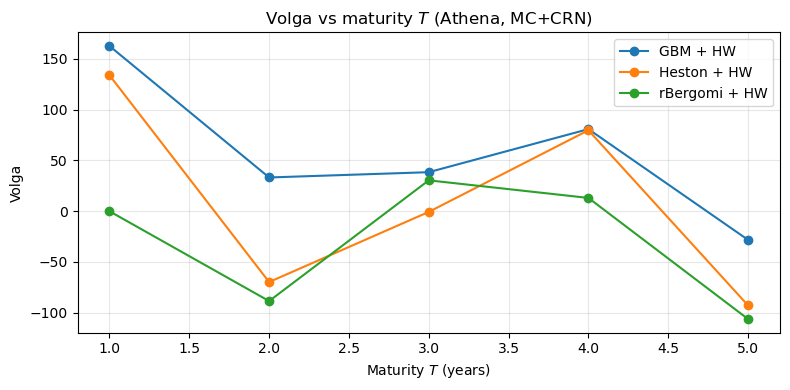

Volatility knob used per model:
Model
GBM + HW            sigma
Heston + HW            v0
rBergomi + HW    rough_nu
Name: VolKnob, dtype: object


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

def obs_per_year_from_freq(obs_freq):
    if obs_freq == ObservationFrequency.ANNUAL:
        return 1
    if obs_freq == ObservationFrequency.SEMIANNUAL:
        return 2
    if obs_freq == ObservationFrequency.QUARTERLY:
        return 4
    if obs_freq == ObservationFrequency.MONTHLY:
        return 12
    raise ValueError(f"Unsupported obs_freq: {obs_freq}")

def greeks_no_theta(model, product, hs=0.005, hv=0.01):
    """
    Compute Price, Delta, Gamma, Vega, Vanna, Volga with CRN.
    Theta is computed separately (because maturity bumps can break monitoring schedule).
    """
    rng_state = copy.deepcopy(model.rng.bit_generator.state)

    V0, se0 = pricer.price(product, model, rng_state=rng_state)

    # Delta/Gamma
    Vm, _ = pricer.price(product, bump_spot(model, -hs), rng_state=rng_state)
    Vp, _ = pricer.price(product, bump_spot(model, +hs), rng_state=rng_state)
    S0 = float(model.s0)
    hS = hs * S0
    delta = (Vp - Vm) / (2.0 * hS)
    gamma = (Vp - 2.0 * V0 + Vm) / (hS * hS)

    # Vega/Volga
    m_vm, knob = bump_vol_knob(model, -hv)
    m_vp, _    = bump_vol_knob(model, +hv)
    Vvm, _ = pricer.price(product, m_vm, rng_state=rng_state)
    Vvp, _ = pricer.price(product, m_vp, rng_state=rng_state)
    vega  = (Vvp - Vvm) / (2.0 * hv)      # per +1% knob if hv=0.01
    volga = (Vvp - 2.0 * V0 + Vvm) / (hv * hv)

    # Vanna (spot-vol cross)
    m_sp = bump_spot(model, +hs)
    m_sm = bump_spot(model, -hs)

    m_sp_vp, _ = bump_vol_knob(m_sp, +hv)
    m_sp_vm, _ = bump_vol_knob(m_sp, -hv)
    m_sm_vp, _ = bump_vol_knob(m_sm, +hv)
    m_sm_vm, _ = bump_vol_knob(m_sm, -hv)

    V_sp_vp, _ = pricer.price(product, m_sp_vp, rng_state=rng_state)
    V_sp_vm, _ = pricer.price(product, m_sp_vm, rng_state=rng_state)
    V_sm_vp, _ = pricer.price(product, m_sm_vp, rng_state=rng_state)
    V_sm_vm, _ = pricer.price(product, m_sm_vm, rng_state=rng_state)

    vanna = (V_sp_vp - V_sp_vm - V_sm_vp + V_sm_vm) / (4.0 * hS * hv)

    return {
        "Price": V0, "SE": se0,
        "Delta": delta, "Gamma": gamma,
        "Vega": vega, "Vanna": vanna, "Volga": volga,
        "VolKnob": knob
    }

def safe_theta_dVdT(model, product):
    """
    Backward maturity theta: (V(T)-V(T-dt))/dt, but only if T-dt still has at least one obs date.
    If not, returns NaN (e.g. annual monitoring at T=1 year).
    """
    rng_state = copy.deepcopy(model.rng.bit_generator.state)
    V0, _ = pricer.price(product, model, rng_state=rng_state)

    dt = 1.0 / float(model.steps_per_year)
    T0 = float(product.maturity_years)
    first_obs = 1.0 / obs_per_year_from_freq(product.obs_freq)

    # If T-dt removes the first observation date, payoff schedule breaks in your product code
    if T0 - dt < first_obs - 1e-12:
        return np.nan

    prod_m = make_athena(T=T0 - dt)
    Vm, _ = pricer.price(prod_m, model, rng_state=rng_state)
    return (V0 - Vm) / dt  # dV/dT approx


T_GRID = np.array([1, 2, 3, 4, 5], dtype=float)
S0_FIXED = 100.0

base_models_T = {
    "GBM + HW": make_model("gbm_hw", n_paths=20_000, steps=52, seed=12345, rho_sr=0.0),
    "Heston + HW": make_model("heston_hw", n_paths=20_000, steps=52, seed=12345, rho_sr=0.0),
    "rBergomi + HW": make_model("rbergomi_hw", n_paths=20_000, steps=52, seed=12345, rho_sr=0.0),
}
for m in base_models_T.values():
    m.s0 = S0_FIXED

rows = []
for T in T_GRID:
    product_T = make_athena(T=float(T))
    for name, base in base_models_T.items():
        m = copy.deepcopy(base)

        out = greeks_no_theta(m, product_T, hs=0.005, hv=0.01)
        out["Theta"] = safe_theta_dVdT(m, product_T)   # safe computation
        out["Model"] = name
        out["T"] = float(T)
        rows.append(out)

dfT = pd.DataFrame(rows)

display(dfT.pivot(index="T", columns="Model", values="Price"))

greeks = ["Price", "Delta", "Gamma", "Vega", "Theta", "Vanna", "Volga"]

for g in greeks:
    plt.figure(figsize=(8,4))
    for name in dfT["Model"].unique():
        sub = dfT[dfT["Model"] == name].sort_values("T").dropna(subset=[g])
        plt.plot(sub["T"], sub[g], marker="o", label=name)
    plt.xlabel("Maturity $T$ (years)")
    plt.ylabel(g)
    plt.title(f"{g} vs maturity $T$ (Athena, MC+CRN)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Volatility knob used per model:")
print(dfT.groupby("Model")["VolKnob"].first())


## Model sensitivities


Loaded xi0 from: data/calib/calib_rbergomi.json (n=3)

Base PV (heston) = 94.003929 (SE=0.111973)
Sweeping: ['s0', 'v0', 'r0', 'kappa', 'theta', 'xi', 'rho_sv']


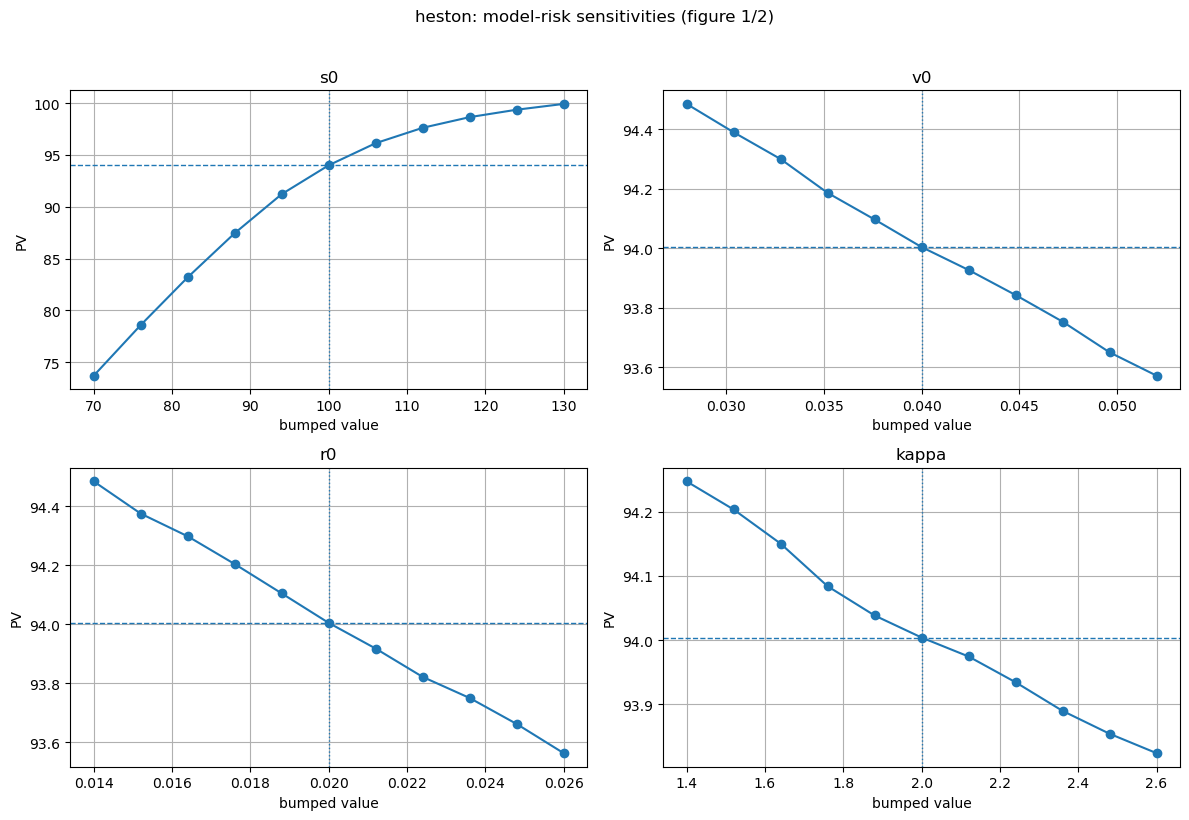

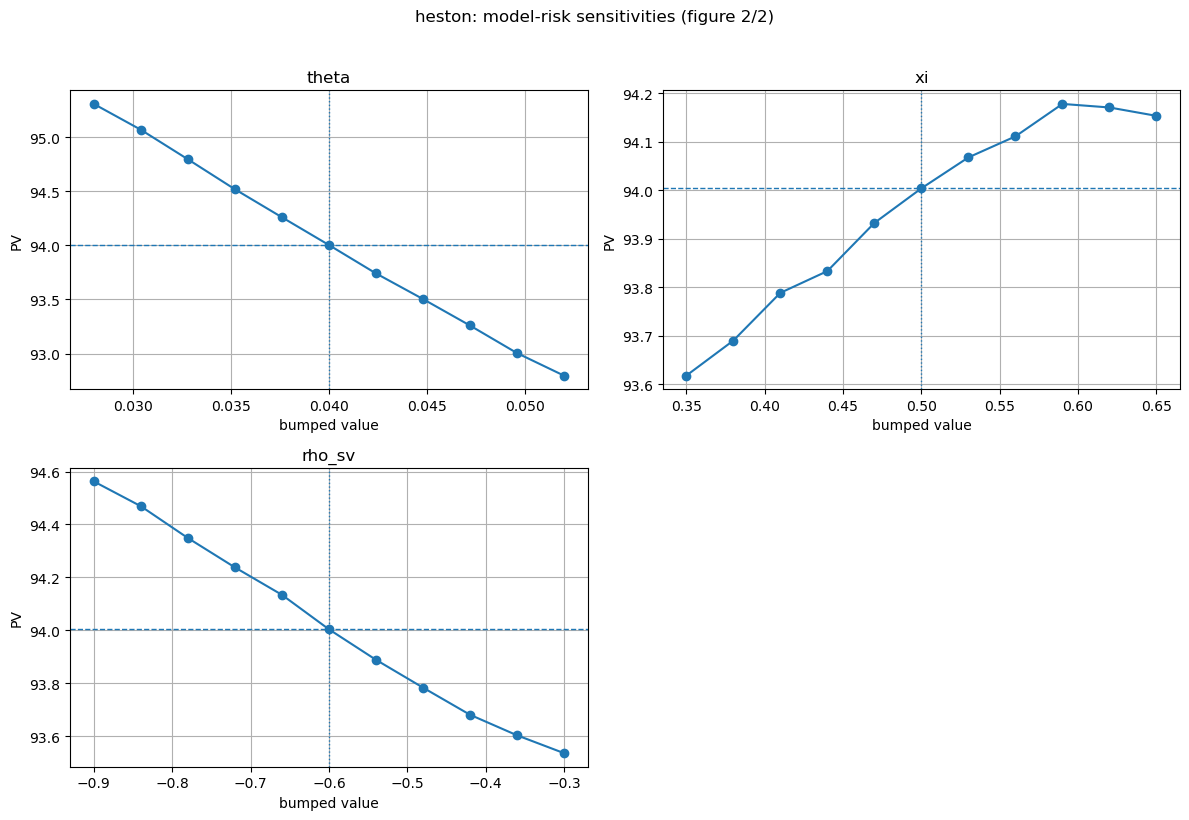


Base PV (rbergomi) = 95.866840 (SE=0.085916)
Sweeping: ['s0', 'rough_nu', 'rough_rho', 'xi0_level', 'r0']


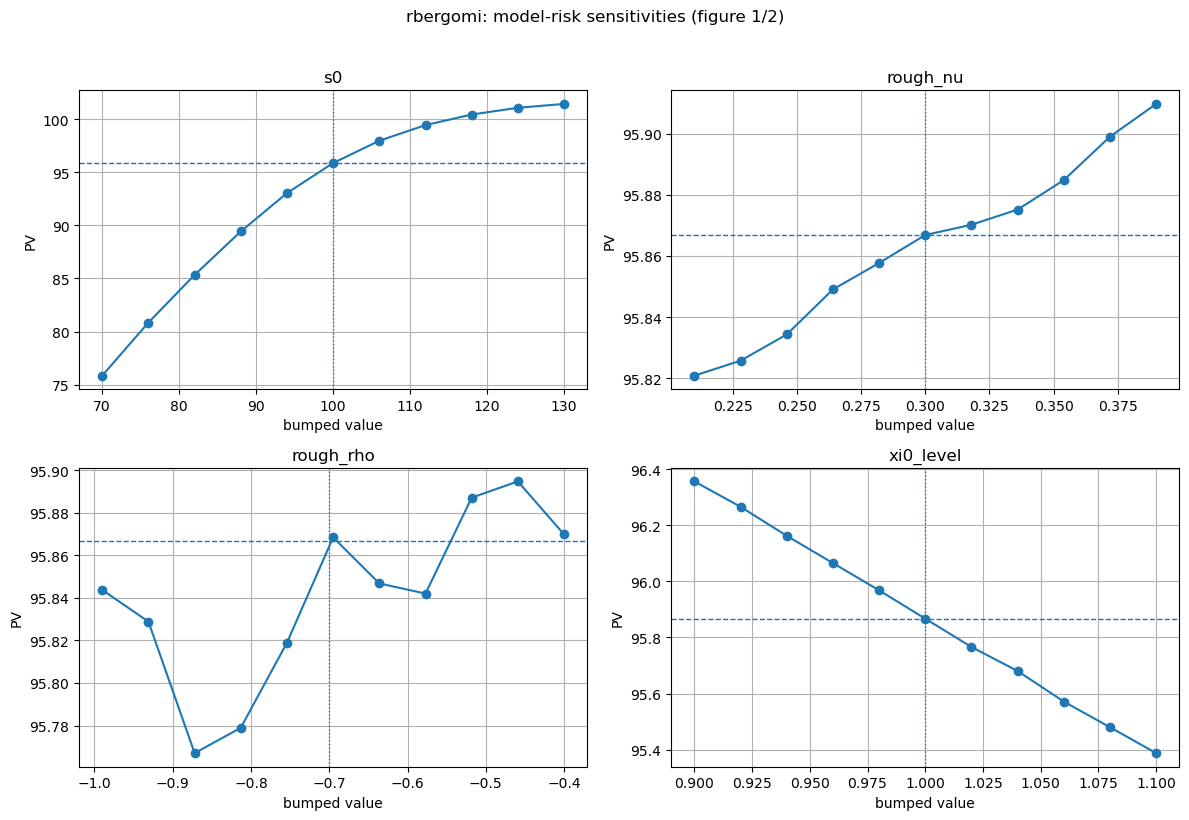

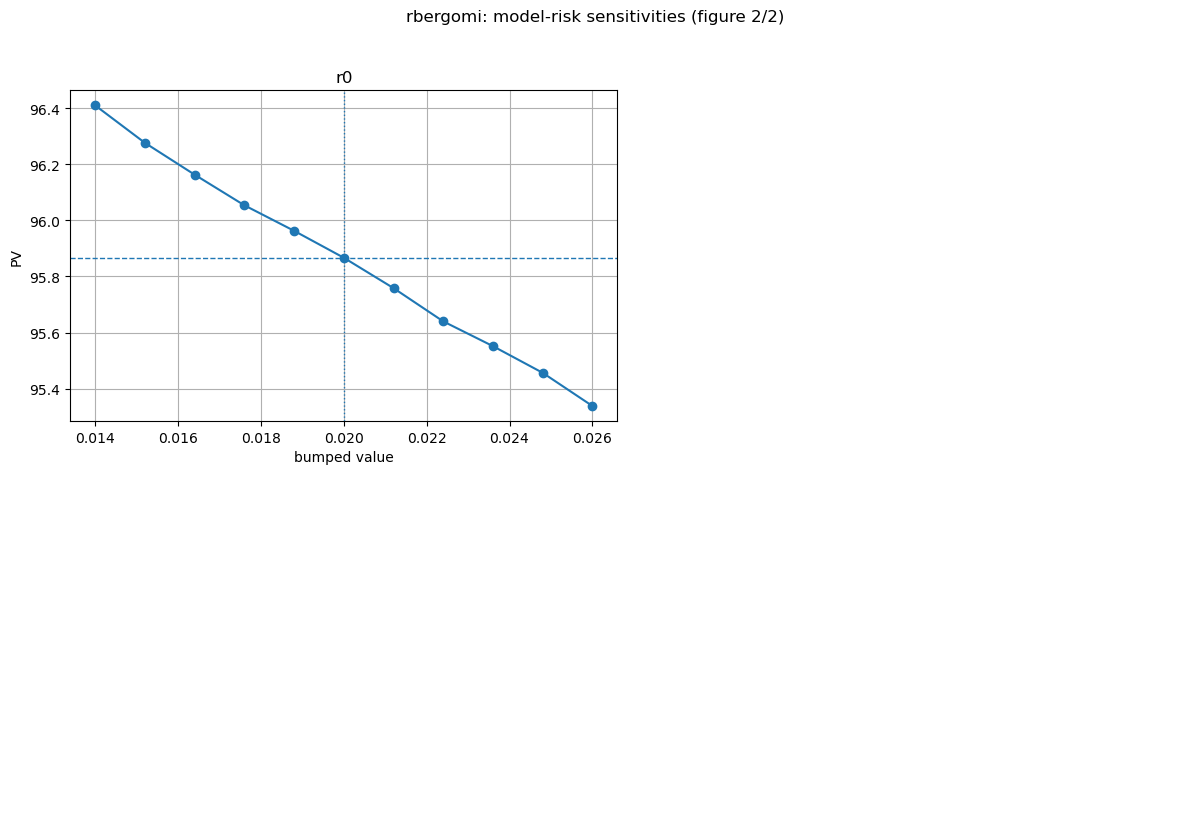


Base PV (gbm_hw) = 92.607708 (SE=0.114839)
Sweeping: []


,model,param,value,pv,se
0,heston,s0,70.0000,73.703081,0.108664
1,heston,s0,76.0000,78.588134,0.117523
2,heston,s0,82.0000,83.196099,0.122770
3,heston,s0,88.0000,87.453619,0.123818
4,heston,s0,94.0000,91.219463,0.119644
5,heston,s0,100.0000,94.003929,0.111973
6,heston,s0,106.0000,96.137383,0.101771
7,heston,s0,112.0000,97.619803,0.091594
8,heston,s0,118.0000,98.648872,0.082506
9,heston,s0,124.0000,99.365527,0.074802


Done.


In [ ]:

import os, json, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

product = make_athena() 


if "pricer" not in globals():
    pricer = MonteCarloPricer(antithetic=True, control_variate=True)

def price_mc(prod, mdl, rng_state=None):
    return pricer.price(prod, mdl, rng_state=rng_state)


def load_xi0_from_calib(calib_dir="data/calib", filename="calib_rbergomi.json"):
    path = os.path.join(calib_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find: {path}")
    with open(path, "r") as f:
        calib = json.load(f)
    if "xi0_times" not in calib or "xi0_values" not in calib:
        raise KeyError(f"Missing xi0_times/xi0_values in {path}. Keys: {list(calib.keys())}")
    xi0_times = np.array(calib["xi0_times"], dtype=float)
    xi0_values = np.array(calib["xi0_values"], dtype=float)
    print(f"Loaded xi0 from: {path} (n={len(xi0_times)})")
    return xi0_times, xi0_values

xi0_times, xi0_values = load_xi0_from_calib("data/calib", "calib_rbergomi.json")


def make_model(model_name: str, **overrides):
    name = model_name.lower().strip()

    disc_times = overrides.pop("disc_times", globals().get("disc_times", None))
    disc_rates = overrides.pop("disc_rates", globals().get("disc_rates", None))

  
    common = dict(
        s0=overrides.pop("s0", 100.0),
        r0=overrides.pop("r0", 0.02),
        sigma=overrides.pop("sigma", 0.20),
        disc_times=disc_times,
        disc_rates=disc_rates,
        steps_per_year=overrides.pop("steps_per_year", getattr(product, "steps_per_year", 252)),
        n_paths=overrides.pop("n_paths", 20_000),
        seed=overrides.pop("seed", 123),
    )

    if name == "heston":
        return Model(
            spot_process="HESTON", rate_process="FLAT", vol_process="FLAT",
            v0=overrides.pop("v0", 0.04),
            kappa=overrides.pop("kappa", 2.0),
            theta=overrides.pop("theta", 0.04),
            xi=overrides.pop("xi", 0.5),
            rho_sv=overrides.pop("rho_sv", -0.6),
            **common, **overrides
        )

    if name == "rbergomi":
        return Model(
            spot_process="GBM", rate_process="FLAT", vol_process="RBERGOMI",
            rough_H=overrides.pop("rough_H", 0.10),
            rough_nu=overrides.pop("rough_nu", 0.30),
            rough_rho=overrides.pop("rough_rho", -0.7),
            xi0_times=overrides.pop("xi0_times", xi0_times),
            xi0_values=overrides.pop("xi0_values", xi0_values),
            **common, **overrides
        )

    if name in ("gbm_hw", "gbm_hullwhite"):
        return Model(
            spot_process="GBM", rate_process="HULLWHITE", vol_process="FLAT",
            a=overrides.pop("a", 0.10),
            b=overrides.pop("b", 0.02),
            sigma_r=overrides.pop("sigma_r", 0.01),
            
            rho_sr=overrides.pop("rho_sr", 0.0),
            **common, **overrides
        )

    raise ValueError(f"Unknown model_name={model_name}")


def bump_model(base: Model, param: str, x: float) -> Model:
    m = copy.deepcopy(base)

   
    if param == "xi0_level":
        if getattr(m, "xi0_values", None) is None:
            raise ValueError("xi0_level bump requested but model.xi0_values is None.")
        m.xi0_values = np.asarray(m.xi0_values, float) * float(x)
        return m

    if param == "disc_rates_parallel":
        if getattr(m, "disc_rates", None) is None:
            raise ValueError("disc_rates_parallel bump requested but model.disc_rates is None.")
        m.disc_rates = np.asarray(m.disc_rates, float) + float(x)
        return m

  
    if not hasattr(m, param):
        raise AttributeError(f"Model has no attribute '{param}'.")
    setattr(m, param, float(x))

   
    if param in ("rho_sv", "rho_sr", "rho_vr", "rough_rho") and hasattr(m, "build_correlation"):
        m.build_correlation()

    return m

def make_grid(base: Model, param: str, n: int = 11):
    if param in ("rho_sv", "rho_sr", "rho_vr", "rough_rho"):
        c0 = float(getattr(base, param))
        return np.linspace(max(-0.99, c0 - 0.30), min(0.99, c0 + 0.30), n)

    if param == "rough_H":
        H0 = float(getattr(base, param))
        return np.linspace(max(0.02, H0 - 0.10), min(0.49, H0 + 0.10), n)

    if param in ("sigma_r", "xi", "rough_nu", "v0", "theta", "kappa", "a", "b", "sigma", "r0", "s0"):
        x0 = float(getattr(base, param))
        return x0 * np.linspace(0.7, 1.3, n) if abs(x0) > 1e-12 else np.linspace(0.0, 1.0, n)

    if param == "disc_rates_parallel":
        return np.linspace(-0.0010, 0.0010, n)  # +/-10bp

    if param == "xi0_level":
        return np.linspace(0.9, 1.1, n)

    # fallback
    x0 = float(getattr(base, param))
    return x0 * np.linspace(0.7, 1.3, n) if abs(x0) > 1e-12 else np.linspace(-1.0, 1.0, n)


def plot_model_sensitivities(model_name: str, n_per_fig: int = 4, n_grid: int = 11):
    base_model = make_model(model_name)

    rng_state0 = copy.deepcopy(base_model.rng.bit_generator.state)
    base_pv, base_se = price_mc(product, base_model, rng_state=rng_state0)
    print(f"\nBase PV ({model_name}) = {base_pv:.6f} (SE={base_se:.6f})")

    params = list(base_model.default_sensitivity_parameters())

    
    if model_name == "rbergomi" and "xi0_level" not in params:
        params.append("xi0_level")

    print("Sweeping:", params)

    chunks = [params[i:i+n_per_fig] for i in range(0, len(params), n_per_fig)]
    all_rows = []

    for chunk_id, chunk in enumerate(chunks, start=1):
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()

        # hide unused axes
        for ax in axes[len(chunk):]:
            ax.axis("off")

        for j, p in enumerate(chunk):
            ax = axes[j]
            grid = make_grid(base_model, p, n=n_grid)

            pv_list = []
            for x in grid:
                m_b = bump_model(base_model, p, x)
                pv, se = price_mc(product, m_b, rng_state=rng_state0)
                pv_list.append(pv)
                all_rows.append({"model": model_name, "param": p, "value": float(x), "pv": float(pv), "se": float(se)})

            # base parameter marker
            if p == "xi0_level":
                x0 = 1.0
            elif p == "disc_rates_parallel":
                x0 = 0.0
            else:
                x0 = float(getattr(base_model, p))

            ax.plot(grid, pv_list, marker="o", linewidth=1.5)
            ax.axhline(base_pv, linestyle="--", linewidth=1.0)  # base PV
            ax.axvline(x0, linestyle=":", linewidth=1.0)        # base param value
            ax.set_title(p)
            ax.grid(True)
            ax.set_xlabel("bumped value")
            ax.set_ylabel("PV")

        fig.suptitle(f"{model_name}: model-risk sensitivities (figure {chunk_id}/{len(chunks)})", y=1.02)
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(all_rows)


models_to_run = ["heston", "rbergomi", "gbm_hw"]

dfs = [plot_model_sensitivities(m) for m in models_to_run]
df_all = pd.concat(dfs, ignore_index=True)
display(df_all.head(30))
print("Done.")
